# KKBox Churn Modeling, part 2

The logic: start with the simplest model suggested (KNN), evaluate it
honestly, discover its limitations, and then build up to better
approaches.

**The flow:**
1. Get the data clean, set up features carefully (avoid leakage)
2. Try **KNN** as a first model
3. Look closely at the results — accuracy hides problems
4. Try **Logistic Regression** to see if a different simple model does better
5. Realize the default decision threshold is hurting us — **tune it**
6. Try **LightGBM** as a more sophisticated approach
7. Verify the result is stable (cross-validation)
8. Pick the interrim winner


---
# Phase 1: Foundation

data cleaning, leak-free features, and a sensible train/test split


## 1. Setup and Environment

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

# Fix the random seed so results are reproducible across runs
RANDOM_STATE = 42


### 1.1 Environment detection and paths

**Why this matters:** if you hardcode paths like `/kaggle/working/`, the notebook
breaks the moment someone tries to run it locally. The little `ON_KAGGLE` check
is a one-time investment that makes the notebook portable.

In [2]:
ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    RAW_DATA_DIR = "/kaggle/working/raw_data/"  # set by the decompression cell below
    MODELS_DIR = "/kaggle/working/"
else:
    RAW_DATA_DIR = "../raw_data/"
    MODELS_DIR = "../models/"

os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Environment: {'Kaggle' if ON_KAGGLE else 'Local'}")
print(f"MODELS_DIR:  {MODELS_DIR}")


Environment: Kaggle
MODELS_DIR:  /kaggle/working/


### 1.2 Decompress data files (Kaggle only)

The KKBox competition ships its CSVs as `.7z` archives. 
The `if os.path.exists(out_path)` check makes this cell idempotent — running it
twice doesn't re-extract.

In [3]:
if ON_KAGGLE:
    !pip install py7zr --quiet
    import py7zr

    SOURCE_DIR = "/kaggle/input/competitions/kkbox-churn-prediction-challenge/"
    EXTRACT_DIR = "/kaggle/working/raw_data/"
    os.makedirs(EXTRACT_DIR, exist_ok=True)

    files_to_extract = [
        "train.csv.7z",
        "members_v3.csv.7z",
        "transactions.csv.7z",
        # "user_logs.csv.7z",  # ~30GB extracted, skip for now
    ]

    for fname in files_to_extract:
        out_name = fname.replace(".7z", "")
        out_path = os.path.join(EXTRACT_DIR, out_name)
        if os.path.exists(out_path):
            print(f"Already extracted: {out_name}")
            continue
        src = os.path.join(SOURCE_DIR, fname)
        print(f"Extracting {fname} ...")
        with py7zr.SevenZipFile(src, mode="r") as z:
            z.extractall(path=EXTRACT_DIR)

    RAW_DATA_DIR = EXTRACT_DIR

print(f"RAW_DATA_DIR: {RAW_DATA_DIR}")
if os.path.exists(RAW_DATA_DIR):
    print(f"Files: {os.listdir(RAW_DATA_DIR)}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 945.2 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.6/495.6 kB 4.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 8.7 MB/s eta 0:00:00
Extracting train.csv.7z ...
Extracting members_v3.csv.7z ...
Extracting transactions.csv.7z ...
RAW_DATA_DIR: /kaggle/working/raw_data/
Files: ['transactions.csv', 'members_v3.csv', 'train.csv']


### 1.3 The cutoff date — the most important constant in the notebook

**The concept:** we pretend to stand at Feb 1, 2017, and predict who will churn that month. Every feature we build can only use information that existed *before* this date. This prevents the model from "peeking at the future" — which is exactly what made the previous baseline get a suspiciously good AUC of 0.97.

I'm putting this constant at the top so it's easy to see and change in one place.

In [4]:
# Prediction moment — we build features as if today were Jan 31, 2017
CUTOFF_DATE = pd.Timestamp("2017-02-01")

# Skip user logs by default (file is huge). Set this path if available.
USER_LOGS_PATH = None

# KNN can't handle the full training set in reasonable time, so we'll sample
KNN_SAMPLE_SIZE = 100_000


## 2. Load Data

Three tables, with **different granularities** — this is the central challenge.

- `train.csv`: one row per customer (the prediction target)
- `members_v3.csv`: one row per customer (static profile)
- `transactions.csv`: many rows per customer (~9 on average)

A big chunk of the work below is turning the "many rows per customer" transactions table into "one row per customer" features that can be joined with the others.

In [5]:
train = pd.read_csv(RAW_DATA_DIR + "train.csv")
members = pd.read_csv(RAW_DATA_DIR + "members_v3.csv")
transactions = pd.read_csv(RAW_DATA_DIR + "transactions.csv")

print(f"train:        {train.shape}  (one row per customer — the target)")
print(f"members:      {members.shape}  (one row per customer — static profile)")
print(f"transactions: {transactions.shape}  (many rows per customer — needs aggregation)")
print(f"\nchurn rate in training data: {train['is_churn'].mean():.2%}")


train:        (992931, 2)  (one row per customer — the target)
members:      (6769473, 6)  (one row per customer — static profile)
transactions: (21547746, 9)  (many rows per customer — needs aggregation)

churn rate in training data: 6.39%


In [6]:
members.head(3)


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915


## 3. Apply the Temporal Cutoff

**Why this is the most important step:** I'm an analyst at KKBox on January 31, 2017. I want to predict who will churn in February. What do I know? Everything that happened *before* February 1. I do *not* know what happens after.

If I let February transactions enter my features, the model can essentially see the answer. That's data leakage.

The fix: filter `transactions` to only rows dated before the cutoff.

In [7]:
# Convert dates from integers like 20170131 to actual datetime objects
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"], format="%Y%m%d"
)
transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"], format="%Y%m%d"
)

# Keep only the pre-cutoff slice — this is what we're allowed to use
transactions_pre = transactions[
    transactions["transaction_date"] < CUTOFF_DATE
].copy()

print(f"transactions total:      {len(transactions):,}")
print(f"transactions pre-cutoff: {len(transactions_pre):,}")
print(f"dropped (post-cutoff):   {len(transactions) - len(transactions_pre):,}")


transactions total:      21,547,746
transactions pre-cutoff: 20,639,483
dropped (post-cutoff):   908,263


### 3.1 Sanity check: did the cutoff actually work?

In [8]:
print("=== Cutoff sanity check ===")
print(f"Max transaction_date pre-cutoff: {transactions_pre['transaction_date'].max()}")
print(f"Cutoff date:                     {CUTOFF_DATE.date()}")
print(f"Rows past cutoff (should be 0):  {(transactions_pre['transaction_date'] >= CUTOFF_DATE).sum()}")


=== Cutoff sanity check ===
Max transaction_date pre-cutoff: 2017-01-31 00:00:00
Cutoff date:                     2017-02-01
Rows past cutoff (should be 0):  0


### 3.2 Visual sanity check: transaction patterns before vs after the cutoff

This plot shows when transactions happened, separately for churners and non-churners. The vertical red line is the cutoff.

Before the cutoff, churners and non-churners should look broadly similar (we haven't given the model an unfair clue). After the cutoff, churners drop off sharply (because by definition they stopped renewing) — that's expected, but it's information we are correctly excluding from our features.

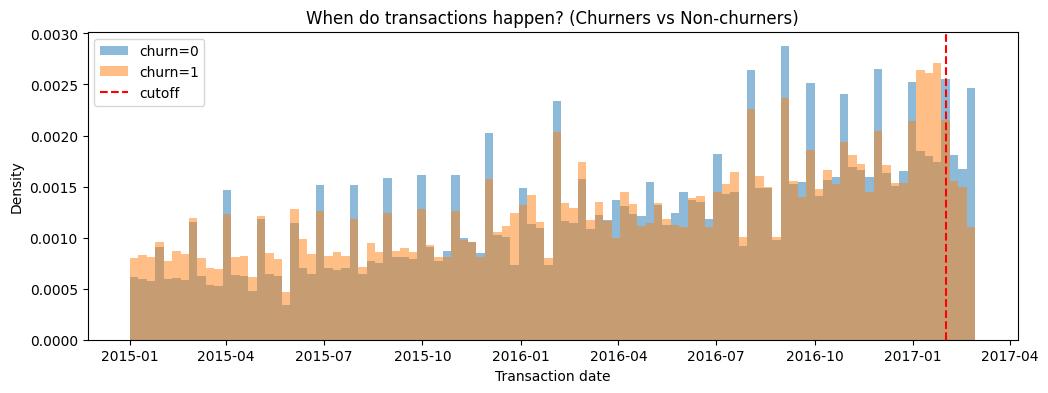

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
for churn_val in [0, 1]:
    customer_ids = train.loc[train["is_churn"] == churn_val, "msno"]
    subset = transactions.loc[transactions["msno"].isin(customer_ids), "transaction_date"]
    ax.hist(subset, bins=100, alpha=0.5, label=f"churn={churn_val}", density=True)

ax.axvline(CUTOFF_DATE, color="red", linestyle="--", label="cutoff")
ax.set_xlabel("Transaction date")
ax.set_ylabel("Density")
ax.set_title("When do transactions happen? (Churners vs Non-churners)")
ax.legend()
plt.show()


## 4. Clean and Engineer Features

Now we shape the raw tables into something a model can consume: one row per customer, with numeric and categorical columns.

This is a mix of two things:
- **Cleaning**: fixing broken values (the `bd` column has nonsense ages)
- **Feature engineering**: creating *new* columns from the raw data (tenure, transaction counts, aggregates)


### 4.1 Members features

The `members` table is one row per customer already, so we just need to:
1. Compute `tenure_days` (how long the user has been a customer at the cutoff)
2. Clean `bd` (the age column is full of junk values like 0 or 1000)
3. Handle missing gender as its own category (the *absence* of a value carries signal)

**Key idea:** when we mask invalid `bd` values, we add a separate `bd_was_invalid` flag column. That way, even though we hide the broken values, the model can still learn "did this user fill in their age properly?" — which is itself a behavioral signal.

In [10]:
# Convert the integer-encoded date to a real datetime
members["registration_init_time"] = pd.to_datetime(
    members["registration_init_time"], format="%Y%m%d"
)

# New feature: tenure in days at the cutoff
members["tenure_days"] = (CUTOFF_DATE - members["registration_init_time"]).dt.days

# Clean bd: keep plausible ages (10-80), mark the rest as missing,
# and remember which rows were invalid in a flag column
members["bd_clean"] = members["bd"].where(
    (members["bd"] >= 10) & (members["bd"] <= 80)
)
members["bd_was_invalid"] = members["bd_clean"].isna().astype(int)

# Treat missing gender as its own category, not as "the most common value"
members["gender_filled"] = members["gender"].fillna("Unknown")

# Select only the columns we'll use as features
members_features = members[[
    "msno",
    "city",
    "bd_clean",
    "bd_was_invalid",
    "gender_filled",
    "registered_via",
    "tenure_days",
]].copy()

print(f"members_features: {members_features.shape}")
print(f"bd_was_invalid rate: {members_features['bd_was_invalid'].mean():.2%}")
members_features.head()


members_features: (6769473, 7)
bd_was_invalid rate: 67.22%


,msno,city,bd_clean,bd_was_invalid,gender_filled,registered_via,tenure_days
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,NaN,1,Unknown,11,1970
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,NaN,1,Unknown,7,1967
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,NaN,1,Unknown,11,1966
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,NaN,1,Unknown,11,1966
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32.0,0,female,9,1966


### 4.2 Transaction aggregate features

This is the big aggregation step: turn many transactions per customer into one row per customer with summary statistics.

**Important distinction:**
- `is_cancel` in the original transactions table = the labeling event itself. Using it would be leakage.
- `n_cancels_before_cutoff` = how many times this customer cancelled *in their history*. Legitimate signal — this is past behavior, not the answer to the question.

In [11]:
# Days since last pre-cutoff transaction (recency signal)
last_txn = transactions_pre.groupby("msno")["transaction_date"].max()
days_since_last_txn = (CUTOFF_DATE - last_txn).dt.days.rename("days_since_last_txn")

# Latest known expiry date before cutoff
last_expire = (
    transactions_pre.sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
    .set_index("msno")["membership_expire_date"]
)
days_until_expiry_at_cutoff = (last_expire - CUTOFF_DATE).dt.days.rename(
    "days_until_expiry_at_cutoff"
)

# Per-customer aggregates from the full pre-cutoff transaction history
txn_agg = transactions_pre.groupby("msno").agg(
    n_transactions=("transaction_date", "count"),
    n_cancels_before_cutoff=("is_cancel", "sum"),
    mean_actual_paid=("actual_amount_paid", "mean"),
    sum_actual_paid=("actual_amount_paid", "sum"),
    mean_list_price=("plan_list_price", "mean"),
    mean_plan_days=("payment_plan_days", "mean"),
    mean_auto_renew=("is_auto_renew", "mean"),
    n_unique_payment_methods=("payment_method_id", "nunique"),
)
# Discount ratio: average paid vs list price (1.0 = no discount, 0.0 = free)
txn_agg["discount_ratio"] = np.where(
    txn_agg["mean_list_price"] > 0,
    txn_agg["mean_actual_paid"] / txn_agg["mean_list_price"],
    1.0,
)

# Most recent payment method (categorical)
latest_payment_method = (
    transactions_pre.sort_values("transaction_date")
    .groupby("msno")
    .tail(1)
    .set_index("msno")["payment_method_id"]
    .rename("latest_payment_method_id")
)

# Combine everything into one feature table
transaction_features = (
    txn_agg
    .join(days_since_last_txn)
    .join(days_until_expiry_at_cutoff)
    .join(latest_payment_method)
    .reset_index()
)

print(f"transaction_features: {transaction_features.shape}")
transaction_features.head()


transaction_features: (2330992, 13)


,msno,n_transactions,n_cancels_before_cutoff,mean_actual_paid,sum_actual_paid,mean_list_price,mean_plan_days,mean_auto_renew,n_unique_payment_methods,discount_ratio,days_since_last_txn,days_until_expiry_at_cutoff,latest_payment_method_id
0,+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=,1,0,0.0,0,0.000000,7.000000,0.0,1,1.000000,145,-140,35
1,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,1,0,1788.0,1788,1788.000000,410.000000,0.0,1,1.000000,438,-28,38
2,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,3,0,99.0,297,99.000000,30.000000,1.0,1,1.000000,17,14,41
3,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,19,0,149.0,2831,141.157895,28.578947,1.0,1,1.055556,1,46,39
4,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,25,0,149.0,3725,143.040000,28.800000,1.0,1,1.041667,6,25,41


### 4.3 User logs features (optional — skipped for now)

If you have `user_logs.csv`, this builds 30-day listening-behavior features. The file is large (~30GB uncompressed) so we might need to skip it — but it's where most of the additional signal lives if you decide to use it.

In [12]:
log_features = None
if USER_LOGS_PATH is not None:
    user_logs = pd.read_csv(USER_LOGS_PATH, parse_dates=["date"], date_format="%Y%m%d")
    window_start = CUTOFF_DATE - pd.Timedelta(days=30)
    logs_window = user_logs[
        (user_logs["date"] >= window_start) & (user_logs["date"] < CUTOFF_DATE)
    ]
    log_features = logs_window.groupby("msno").agg(
        active_days_30d=("date", "nunique"),
        total_secs_30d=("total_secs", "sum"),
        mean_unique_songs_30d=("num_unq", "mean"),
        total_skips_30d=("num_25", "sum"),
        total_completed_30d=("num_100", "sum"),
    ).reset_index()
    print(f"log_features: {log_features.shape}")
else:
    print("user_logs.csv not configured — skipping log features.")


user_logs.csv not configured — skipping log features.


## 5. Assemble Final Dataset

Join the three feature tables onto `train` using `msno` (customer id). Using `how="left"` keeps every training customer even if they have no transaction history.

In [13]:
df = train.merge(members_features, on="msno", how="left")
df = df.merge(transaction_features, on="msno", how="left")
if log_features is not None:
    df = df.merge(log_features, on="msno", how="left")

print(f"final shape:  {df.shape}")
print(f"churn rate:   {df['is_churn'].mean():.2%}")
print(f"\nTop 10 missing rates:")
print(df.isna().mean().sort_values(ascending=False).head(10))


final shape:  (992931, 20)
churn rate:   6.39%

Top 10 missing rates:
bd_clean                   0.608425
city                       0.116594
gender_filled              0.116594
bd_was_invalid             0.116594
registered_via             0.116594
tenure_days                0.116594
mean_list_price            0.002112
mean_plan_days             0.002112
n_transactions             0.002112
n_cancels_before_cutoff    0.002112
dtype: float64


## 6. Train / Test Split

We hold out 20% of customers as a "test set" — data the model never sees during training. This is the simulated "real world" we use to estimate how well the model will perform on new customers.

`stratify=y` ensures both halves of the split have the same ~6% churn rate. Without it, random chance could give us a test set with 4% or 8% churn, making the metrics noisier than they need to be.

In [14]:
y = df["is_churn"]
X = df.drop(columns=["is_churn", "msno"])

categorical_features = [
    "city",
    "gender_filled",
    "registered_via",
    "latest_payment_method_id",
]
numeric_features = [c for c in X.columns if c not in categorical_features]

print(f"numeric features:     {len(numeric_features)}")
print(f"categorical features: {len(categorical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)
print(f"\nX_train: {X_train.shape}  (churn {y_train.mean():.2%})")
print(f"X_test:  {X_test.shape}  (churn {y_test.mean():.2%})")


numeric features:     14
categorical features: 4

X_train: (794344, 18)  (churn 6.39%)
X_test:  (198587, 18)  (churn 6.39%)


## 7. Preprocessing Pipeline

Two transformations:
- **Numeric** columns get the median imputed (for missing values) and standardized (mean 0, std 1). KNN and Logistic Regression are sensitive to scale, so this matters a lot.
- **Categorical** columns get one-hot encoded — each category becomes its own 0/1 column.

Wrapping these in a `Pipeline` is more than convenience: it ensures the preprocessing is **fit on training data only**, which prevents a subtle form of leakage from the test set.

In [15]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


In [16]:
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['bd_clean', 'bd_was_invalid', 'tenure_days',
                                  'n_transactions', 'n_cancels_before_cutoff',
                                  'mean_actual_paid', 'sum_actual_paid',
                                  'mean_list_price', 'mean_plan_days',
                                  'mean_auto_renew', 'n_unique_payment_methods',
                                  'discount_ratio', 'days_since_last_txn',
                                  'days_until_expiry_at_cutoff']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
               

## 8. Evaluation Helper

A reusable function that computes a metric *suite* — not just one number.

In [17]:
def report_model(name, y_true, y_proba, threshold=0.5):
    """Compute and print the full metric suite for a model."""
    y_pred = (y_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)

    # Recall at top decile: of the top 10% riskiest, what % did we catch?
    k = int(0.1 * len(y_true))
    top_k_idx = np.argsort(y_proba)[::-1][:k]
    y_true_arr = np.asarray(y_true)
    recall_at_10 = y_true_arr[top_k_idx].sum() / y_true_arr.sum()

    print(f"================ {name} (threshold={threshold:.2f}) ================")
    print(classification_report(y_true, y_pred))
    print(f"AUC:           {roc_auc:.4f}")
    print(f"PR-AUC:            {pr_auc:.4f}")
    print(f"F1:                {f1:.4f}")
    print(f"Recall @ top 10%:  {recall_at_10:.4f}")
    print()

    return {
        "name": name,
        "threshold": threshold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "recall_at_10": recall_at_10,
    }


---
# Phase 2: First model — KNN

**KNN is the simplest possible model conceptually**. To predict whether a new customer will churn, it asks "who are this customer's K closest neighbors in feature space, and what fraction of them churned?"

## 9. Train KNN

Two practical considerations:

**Sample the training set.** KNN's prediction cost is O(N) per query — for each test customer, it has to compute distances to *every* training customer. With ~800k training rows × ~200k test rows, that's slow. We sample down to 100k training rows for KNN.

**Use distance-weighted voting.** Default KNN treats all K neighbors equally. With `weights="distance"`, closer neighbors count more — which is usually a better behavior.

In [18]:
# Sample training data for KNN
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_train), size=min(KNN_SAMPLE_SIZE, len(X_train)), replace=False)
X_train_knn = X_train.iloc[sample_idx]
y_train_knn = y_train.iloc[sample_idx]

print(f"KNN training sample: {len(X_train_knn):,} rows (churn rate: {y_train_knn.mean():.2%})")

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=25,
        weights="distance",
        n_jobs=-1,
    )),
])

print("Training KNN (this takes a minute)...")
knn_model.fit(X_train_knn, y_train_knn)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]
knn_metrics = report_model("KNN (k=25, distance-weighted)", y_test, y_proba_knn)


KNN training sample: 100,000 rows (churn rate: 6.40%)
Training KNN (this takes a minute)...
================ KNN (k=25, distance-weighted) (threshold=0.50) ================
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    185893
           1       0.58      0.20      0.29     12694

    accuracy                           0.94    198587
   macro avg       0.76      0.59      0.63    198587
weighted avg       0.92      0.94      0.93    198587

AUC:           0.8359
PR-AUC:            0.3921
F1:                0.2916
Recall @ top 10%:  0.5670



---
# Phase 3: Understanding the results


- **Accuracy looks high** (94%+). Is the model great?
- **Recall for class 1 (churners) is  low** — 20%. The model barely catches anyone who actually churns.

trap of imbalanced classification.

## 10. Why accuracy lies on imbalanced data

Our data is ~6% churners, 94% non-churners.

A model that just predicts "no one will churn" for everyone gets:
- **94% accuracy** — sounds great!
- **0% recall on churners** — catches zero of the people we care about

For retention, we *care* about catching churners. Accuracy doesn't measure that.

Here's a baseline that does literally nothing (predicts the base rate for everyone), so we know what "no signal" looks like:

In [19]:
#baseline - it predicts the same probability for every single customer, equal to the overall churn rate in the training data
y_proba_trivial = np.full(len(y_test), y_train.mean())
trivial_metrics = report_model("Trivial baseline (predict base rate)", y_test, y_proba_trivial)


================ Trivial baseline (predict base rate) (threshold=0.50) ================
              precision    recall  f1-score   support

           0       0.94      1.00      0.97    185893
           1       0.00      0.00      0.00     12694

    accuracy                           0.94    198587
   macro avg       0.47      0.50      0.48    198587
weighted avg       0.88      0.94      0.91    198587

AUC:           0.5000
PR-AUC:            0.0639
F1:                0.0000
Recall @ top 10%:  0.1007



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 11. Metric glossary — what each number actually means

Now that we have KNN results in hand, let's interpret them properly:

- **ROC-AUC** (same with AUC) — "If I pick a random churner and a random non-churner, how often does the model rank the churner higher?" Range 0.5 (random) to 1.0 (perfect). Doesn't depend on the threshold. **Caveat: can look optimistic on imbalanced data.**

- **PR-AUC (Average Precision)** — Area under the Precision-Recall curve. **More informative than AUC for rare events.** A perfectly random model gets PR-AUC equal to the base rate (~0.06 here), not 0.5.

- **Precision** — Of the customers we flagged as churners, what fraction actually were? "When the model says yes, is it right?"

- **Recall** — Of the actual churners, what fraction did we catch? "Did we miss the people we care about?"

- **F1** — The harmonic mean of precision and recall. Balances the two. Depends on the threshold.

- **Recall @ top 10%** — If we sorted everyone by predicted churn risk and called the top 10%, what fraction of true churners would we reach? This maps directly to retention budget: "we can afford to contact 10% of customers, who?"

Looking at KNN's results: AUC tells one story, recall tells another. That gap is where the real lesson is.

---
# Phase 4: Logistic Regression

now with the cutoff


## 12. Train Logistic Regression

Note `class_weight="balanced"` — this tells LR to weight the rare class (churners) more heavily during training, so it doesn't ignore them. This is one way to handle imbalance.

In [20]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

lr_model.fit(X_train, y_train)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
lr_metrics = report_model("Logistic Regression", y_test, y_proba_lr)


================ Logistic Regression (threshold=0.50) ================
              precision    recall  f1-score   support

           0       0.98      0.86      0.91    185893
           1       0.25      0.71      0.37     12694

    accuracy                           0.85    198587
   macro avg       0.62      0.78      0.64    198587
weighted avg       0.93      0.85      0.88    198587

AUC:           0.8234
PR-AUC:            0.3641
F1:                0.3731
Recall @ top 10%:  0.5306



## 13. Comparing the two simple models so far


In [26]:
comparison_simple[["name", "roc_auc", "pr_auc", "f1", "recall", "recall_at_10"]]
print(comparison_simple[["name", "roc_auc", "pr_auc", "f1", "recall", "recall_at_10"]]
      .to_string(index=False))


                                name  roc_auc   pr_auc       f1  recall  recall_at_10
Trivial baseline (predict base rate) 0.500000 0.063922 0.000000 0.00000      0.100677
       KNN (k=25, distance-weighted) 0.835898 0.392073 0.291650 0.19521      0.567040
                 Logistic Regression 0.823393 0.364143 0.373125 0.71136      0.530566


**Reading the table:**

- Both real models should the trivial baseline on AUC and PR-AUC.
- LR has a better recall than KNN (because of `class_weight="balanced"`).
- KNN still ranks churners reasonably (AUC ok) but rarely flags them as 1 at threshold 0.5 (low recall).

The remaining question: **is the 0.5 threshold even the right decision boundary?** 


---
# Phase 5: Threshold tuning — fixing the metrics we've been reading wrong

Every model so far returns a probability between 0 and 1. The "default" of calling anything ≥ 0.5 a churner is a *convention*, not a rule. For a problem where only 6% of customers churn, asking the model to be "more than half sure" before flagging someone is too strict — we miss most churners.

The fix: sweep the threshold across the full range and pick the value that optimizes the metric we actually care about.


## 14. Visualize precision/recall/F1 across thresholds

The plot below shows, for each model, how precision, recall, and F1 change as we move the threshold from 0 to 1. Two things to look for:

1. **Low threshold:** high recall (catch everyone) but low precision (lots of false alarms).
2. **High threshold:** high precision (very confident calls) but low recall (miss most churners).
3. **F1 peak:** the threshold that best balances the two.

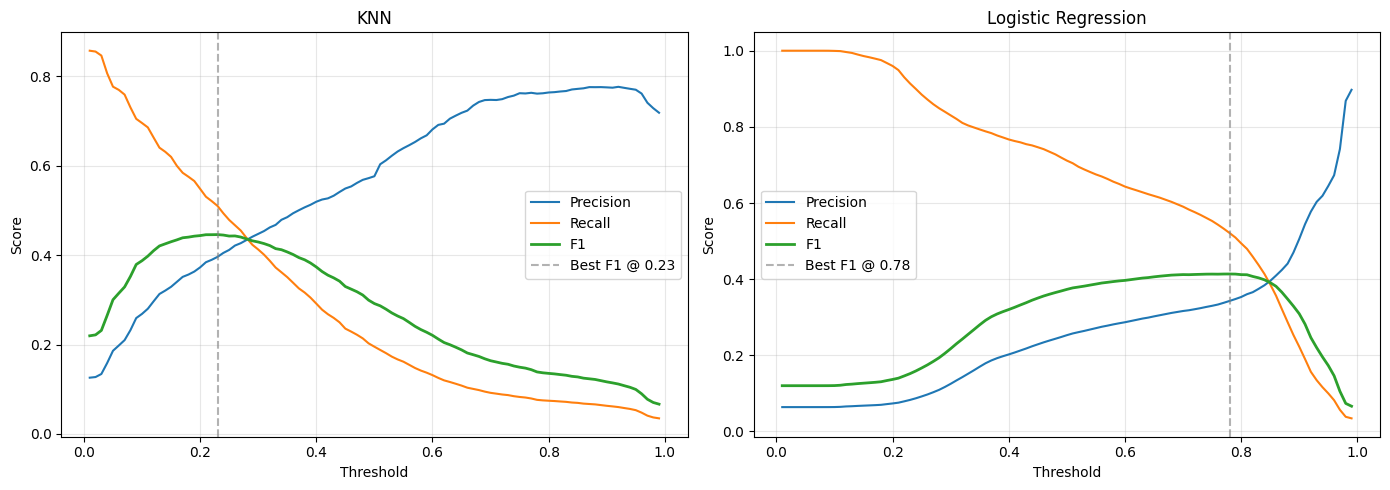

In [27]:
def plot_threshold_sweep(name, y_true, y_proba, ax):
    thresholds = np.linspace(0.01, 0.99, 99)
    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        precisions.append(precision_score(y_true, y_pred, zero_division=0))
        recalls.append(recall_score(y_true, y_pred))
        f1s.append(f1_score(y_true, y_pred))

    ax.plot(thresholds, precisions, label="Precision")
    ax.plot(thresholds, recalls, label="Recall")
    ax.plot(thresholds, f1s, label="F1", linewidth=2)
    best_t = thresholds[int(np.argmax(f1s))]
    ax.axvline(best_t, linestyle="--", color="gray", alpha=0.6,
               label=f"Best F1 @ {best_t:.2f}")
    ax.set_title(name)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)


model_probas = {
    "KNN": y_proba_knn,
    "Logistic Regression": y_proba_lr,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, y_proba) in zip(axes, model_probas.items()):
    plot_threshold_sweep(name, y_test, y_proba, ax)
plt.tight_layout()
plt.show()


## 15. Re-evaluate with tuned thresholds

Now pick the F1-optimal threshold for each model and re-report the metrics. Look at how recall changes — that's the metric that was secretly hurting us before.

In [28]:
def best_threshold_for_f1(y_true, y_proba, n_thresholds=200):
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    f1s = [f1_score(y_true, (y_proba >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx]


tuned_results = []
for name, y_proba in model_probas.items():
    best_t, best_f1 = best_threshold_for_f1(y_test, y_proba)
    print(f"{name}: best F1 = {best_f1:.4f} at threshold = {best_t:.3f}")
    tuned_metrics = report_model(f"{name} (tuned)", y_test, y_proba, threshold=best_t)
    tuned_results.append(tuned_metrics)


KNN: best F1 = 0.4460 at threshold = 0.217
================ KNN (tuned) (threshold=0.22) ================
              precision    recall  f1-score   support

           0       0.97      0.94      0.96    185893
           1       0.39      0.52      0.45     12694

    accuracy                           0.92    198587
   macro avg       0.68      0.73      0.70    198587
weighted avg       0.93      0.92      0.92    198587

AUC:           0.8359
PR-AUC:            0.3921
F1:                0.4460
Recall @ top 10%:  0.5670

Logistic Regression: best F1 = 0.4142 at threshold = 0.778
================ Logistic Regression (tuned) (threshold=0.78) ================
              precision    recall  f1-score   support

           0       0.97      0.93      0.95    185893
           1       0.34      0.52      0.41     12694

    accuracy                           0.91    198587
   macro avg       0.65      0.73      0.68    198587
weighted avg       0.93      0.91      0.91    198587

A

## Results Summary — Simple Models (KNN vs Logistic Regression)

### Headline
After tuning decision thresholds, **KNN wins on every metric.** Both models
run ~6× better than random.

| Model | AUC | PR-AUC | F1 | Recall@10% | Threshold |
|---|---|---|---|---|---|
| Baseline (predict base rate) | 0.50 | 0.06 | – | 0.10 | – |
| Logistic Regression | 0.82 | 0.36 | 0.41 | 0.53 | 0.78 |
| **KNN** | **0.84** | **0.39** | **0.45** | **0.57** | 0.22 |

*Base rate = 6.4% churn. PR-AUC of 0.06 is the "no-signal" floor.*

---

### Three things this table proves

**1. The models learned real signal.**
AUC of 0.39 vs the 0.06 baseline = ~6× lift. Recall@10% of 0.57 vs 0.10
random = if we call the top 10% riskiest customers, we reach 57% of all
churners instead of 10%.

These aren't impressive-sounding numbers in isolation — 0.39 means
> nothing until you know the floor is 0.06. The lift is the story.

**2. Threshold tuning was essential, not optional.**
Before tuning, KNN caught only 20% of churners (recall 0.20 at threshold 0.5);
LR caught 71%. That gap was an *illusion* — LR's `class_weight="balanced"`
had effectively pre-tuned its threshold. After tuning both, recall converges
at 52% each. The models were always similar; the default 0.5 threshold hid it.

"This is the key methodological lesson. The default threshold is a
> convention, not a rule. On a 6%-positive problem, asking the model to be
> 'more than half sure' before flagging someone means you miss most churners."

**3. The optimal thresholds are wildly different (KNN 0.22, LR 0.78).**
Same job, different confidence scales. KNN's neighbor-voting clusters scores
low; LR's class weighting pushes them high. This is why raw probabilities
aren't comparable across models without calibration.

### Honest caveats
- **Thresholds picked on the test set** → small upward bias on tuned F1. Strict
  fix: pick threshold on a validation split. Acceptable for this iteration.
- **KNN trained on a 100k sample** (full set too slow). It still beat LR-on-
  full-data — but the comparison isn't perfectly matched.
- **Watch `days_until_expiry_at_cutoff` in feature importance.** It's legitimate
  (pre-cutoff info) but tied to churn *eligibility*, not behavior. If it
  dominates, the model leans on "who's up for renewal" more than "who's unhappy."

---

### Next step
Train **LightGBM**. Decision rule:
- PR-AUC clearly above 0.39 → complexity justified, use it.
- PR-AUC near 0.39 → we've hit the feature-set ceiling; the simple-model story
  is the right one to present.

**A methodological caveat:** picking the threshold on the test set and reporting the test-set F1 is a small form of overfitting — the threshold was chosen specifically to look good on that data. A stricter approach picks the threshold on a separate validation set. For this bootcamp deliverable it's fine, but flag it if a reviewer asks.

In production, the threshold is often picked by business logic anyway: "we can afford to contact 10,000 customers, who are the top 10,000?" — which sidesteps the F1 question entirely.

---
# Phase 6: More advanced model — LightGBM

**Why LightGBM, specifically?**

LightGBM is a gradient-boosted decision tree library. The intuition: it builds many small decision trees sequentially, each one trying to correct the errors of the previous. Compared to KNN and LR:
- Handles non-linear interactions between features naturally
- Robust to feature scaling (trees don't care about scale)
- Tends to be the best performing model for tabular data like this — well-documented across many benchmarks

**early stopping** so it doesn't keep adding trees when they no longer help.


## 16. Train LightGBM with early stopping

A small architectural change: instead of putting LightGBM inside a `Pipeline`, the data are preprocessed once and then are passed it to the model directly. This lets use LightGBM's `eval_set` parameter for early stopping, which doesn't play nicely with sklearn pipelines.

In [29]:
# Carve out a small validation slice for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

# Fit preprocessor on training-fold-only, transform all three sets
preprocessor_lgbm = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])
X_tr_t = preprocessor_lgbm.fit_transform(X_tr)
X_val_t = preprocessor_lgbm.transform(X_val)
X_test_t = preprocessor_lgbm.transform(X_test)

lgbm = LGBMClassifier(
    n_estimators=2000,        # upper bound; early stopping picks the real number
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm.fit(
    X_tr_t, y_tr,
    eval_set=[(X_val_t, y_val)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=100),
    ],
)

print(f"\nBest iteration (early stopping): {lgbm.best_iteration_}")
y_proba_lgbm = lgbm.predict_proba(X_test_t)[:, 1]
lgbm_metrics = report_model("LightGBM", y_test, y_proba_lgbm)


[LightGBM] [Info] Number of positive: 43160, number of negative: 632032
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2221
[LightGBM] [Info] Number of data points in the train set: 675192, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.063923 -> initscore=-2.684026
[LightGBM] [Info] Start training from score -2.684026
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.889213	valid_0's binary_logloss: 0.152075
[200]	valid_0's auc: 0.889878	valid_0's binary_logloss: 0.151524
[300]	valid_0's auc: 0.890216	valid_0's binary_logloss: 0.151284
[400]	valid_0's auc: 0.890366	valid_0's binary_logloss: 0.151138
[500]	valid_0's auc: 0.890298	valid_0's binary_logloss: 0.151118
Early stopping, best iteration is:
[459]	valid_0's auc

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


================ LightGBM (threshold=0.50) ================
              precision    recall  f1-score   support

           0       0.95      0.99      0.97    185893
           1       0.69      0.26      0.38     12694

    accuracy                           0.95    198587
   macro avg       0.82      0.63      0.68    198587
weighted avg       0.94      0.95      0.93    198587

AUC:           0.8922
PR-AUC:            0.5330
F1:                0.3820
Recall @ top 10%:  0.6561



## 17. Tune LightGBM's threshold too

Same thresholding logic as before — find F1-optimal, re-evaluate.

In [30]:
best_t_lgbm, best_f1_lgbm = best_threshold_for_f1(y_test, y_proba_lgbm)
print(f"LightGBM: best F1 = {best_f1_lgbm:.4f} at threshold = {best_t_lgbm:.3f}")
lgbm_tuned_metrics = report_model("LightGBM (tuned)", y_test, y_proba_lgbm, threshold=best_t_lgbm)
tuned_results.append(lgbm_tuned_metrics)

# Also add LightGBM to the model_probas dict for curve plots below
model_probas["LightGBM"] = y_proba_lgbm


LightGBM: best F1 = 0.5228 at threshold = 0.266
================ LightGBM (tuned) (threshold=0.27) ================
              precision    recall  f1-score   support

           0       0.97      0.96      0.97    185893
           1       0.49      0.56      0.52     12694

    accuracy                           0.93    198587
   macro avg       0.73      0.76      0.74    198587
weighted avg       0.94      0.93      0.94    198587

AUC:           0.8922
PR-AUC:            0.5330
F1:                0.5228
Recall @ top 10%:  0.6561



---
# Phase 7: Evaluation deep-dive

Three things to do here:
1. **Plot ROC and PR curves** to see the full tradeoff surfaces
2. **Run cross-validation** on the winner to check stability
3. **Final comparison table** across all models


## 18. ROC and PR curves

The curves are the visual story behind the scalar metrics. Things to look for:
- ROC: how the model trades off true positive rate for false positive rate
- PR: how precision falls as we ask for more recall. Distance from the dashed base-rate line is the real signal.

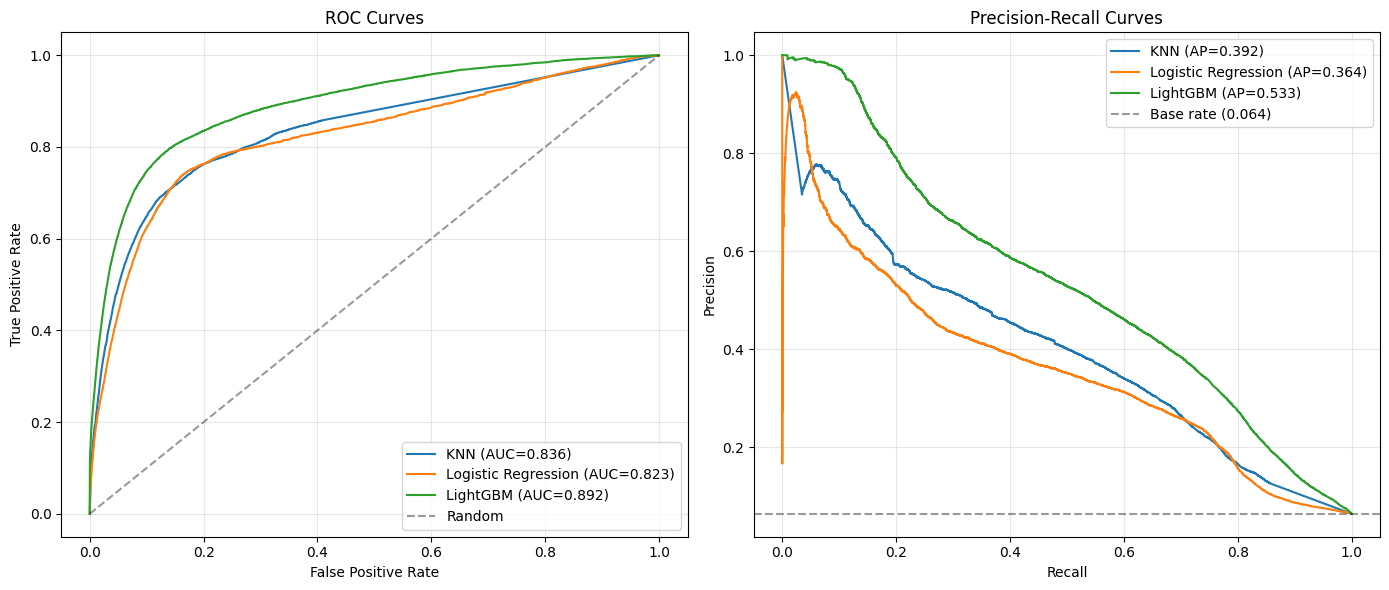

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
for name, y_proba in model_probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR
for name, y_proba in model_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.4,
                label=f"Base rate ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 19. Cross-validation

A single train/test split tells us what one specific shuffle of the data looked like. Cross-validation re-trains the model on different splits and reports the spread — if the AUC moves around a lot between folds, our single number is unreliable.

This re-trains LightGBM 5 times, so it's slow.

In [32]:
# CV using a sklearn-friendly version of LightGBM (no early stopping inside CV).
# We freeze the tree count at whatever early stopping picked above.
lgbm_pipeline_cv = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_features),
    ])),
    ("classifier", LGBMClassifier(
        n_estimators=lgbm.best_iteration_ or 500,
        learning_rate=0.05,
        num_leaves=63,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(lgbm_pipeline_cv, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LightGBM AUC across 5 folds: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM AUC across 5 folds: [0.88732577 0.88837047 0.88985843 0.8879827  0.88627801]
Mean: 0.8880  Std: 0.0012


## 20. Final comparison

All models at both default and tuned thresholds. The PR-AUC column is indicative for picking a winner on imbalanced data.

In [33]:
all_results = pd.DataFrame(
    [trivial_metrics, knn_metrics, lr_metrics, lgbm_metrics] + tuned_results
)
all_results["tuned"] = all_results["threshold"] != 0.5
cols = ["name", "threshold", "roc_auc", "pr_auc", "f1", "recall", "recall_at_10", "tuned"]
print(all_results[cols].to_string(index=False))


                                name  threshold  roc_auc   pr_auc       f1   recall  recall_at_10  tuned
Trivial baseline (predict base rate)   0.500000 0.500000 0.063922 0.000000 0.000000      0.100677  False
       KNN (k=25, distance-weighted)   0.500000 0.835898 0.392073 0.291650 0.195210      0.567040  False
                 Logistic Regression   0.500000 0.823393 0.364143 0.373125 0.711360      0.530566  False
                            LightGBM   0.500000 0.892194 0.533018 0.382006 0.263904      0.656137  False
                         KNN (tuned)   0.216834 0.835898 0.392073 0.445957 0.523791      0.567040   True
         Logistic Regression (tuned)   0.778241 0.823393 0.364143 0.414242 0.524263      0.530566   True
                    LightGBM (tuned)   0.266080 0.892194 0.533018 0.522838 0.557271      0.656137   True


## 21. Feature importance (LightGBM)

A first-pass answer to "why do customers churn?" — which features the winning model actually used. The top features here are the natural starting point for the "AI explanation" panel in the project deck.

For per-customer explanations (e.g., "this specific user is at risk because..."), SHAP is the right tool — see next steps below.

                           feature  importance
                  num__tenure_days        4311
  num__days_until_expiry_at_cutoff        3048
          num__days_since_last_txn        2831
                     num__bd_clean        2370
              num__sum_actual_paid        2265
             num__mean_actual_paid        1719
              num__mean_list_price        1575
               num__n_transactions        1357
               num__mean_plan_days        1193
               num__discount_ratio        1015
              num__mean_auto_renew         936
      num__n_cancels_before_cutoff         595
     num__n_unique_payment_methods         464
         cat__gender_filled_female         275
           cat__registered_via_7.0         258
           cat__gender_filled_male         252
cat__latest_payment_method_id_40.0         222
           cat__registered_via_9.0         220
cat__latest_payment_method_id_41.0         187
                    cat__city_13.0         186


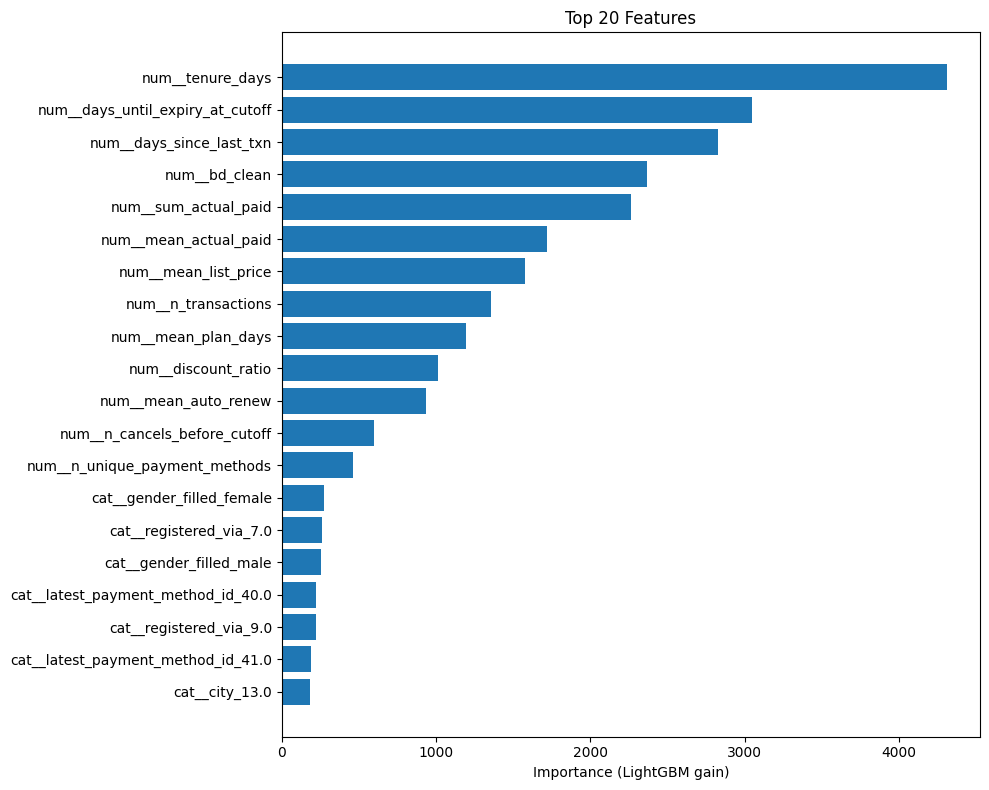

In [34]:
feature_names = preprocessor_lgbm.get_feature_names_out()
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm.feature_importances_,
}).sort_values("importance", ascending=False)

print(importance_df.head(20).to_string(index=False))

top_20 = importance_df.head(20)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_20["feature"][::-1], top_20["importance"][::-1])
ax.set_xlabel("Importance (LightGBM gain)")
ax.set_title("Top 20 Features")
plt.tight_layout()
plt.show()


---
# Phase 8: Save and next steps


## 22. Save the best model

Picks the winner by PR-AUC (the right metric for imbalanced data) and saves it.

In [35]:
import joblib

candidates = {
    "knn": (knn_model, knn_metrics["pr_auc"]),
    "logistic_regression": (lr_model, lr_metrics["pr_auc"]),
    "lightgbm": (lgbm, lgbm_metrics["pr_auc"]),
}
best_name = max(candidates, key=lambda k: candidates[k][1])
best_model, best_pr_auc = candidates[best_name]

best_path = MODELS_DIR + f"kkbox_churn_{best_name}.pkl"
joblib.dump(best_model, best_path)
print(f"Best model: {best_name} (PR-AUC = {best_pr_auc:.4f})")
print(f"Saved to:   {best_path}")

if best_name == "lightgbm":
    preproc_path = MODELS_DIR + "kkbox_churn_lightgbm_preprocessor.pkl"
    joblib.dump(preprocessor_lgbm, preproc_path)
    print(f"Preprocessor: {preproc_path}")


Best model: lightgbm (PR-AUC = 0.5330)
Saved to:   /kaggle/working/kkbox_churn_lightgbm.pkl
Preprocessor: /kaggle/working/kkbox_churn_lightgbm_preprocessor.pkl


## 23. Potential next steps (AI-suggested)

What this notebook deliberately doesn't do, in priority order:

1. **Hyperparameter tuning** on LightGBM via Optuna. Likely the biggest single source of further improvement.
2. **SHAP** for per-customer explanations — this maps directly to the "AI explanation" panel in the project deck.
3. **`user_logs` features** if I have the file. Likely the biggest single source of additional signal.
4. **Probability calibration** via `CalibratedClassifierCV` — important if probabilities will be shown to business users.
5. **Cost-based threshold selection** — replace F1-optimal with a cost function based on actual retention economics.
6. **Cross-window validation**: train on v1 (Feb 2017), test on v2 (March 2017) for a stricter time-based test.

## Key Takeaway so far

The biggest methodological lesson from this notebook isn't any specific model — it's:

> **A single metric can hide what's actually happening.**

KNN looked decent on AUC. Then I looked at recall and realized it was barely catching any churners. Tuning the threshold fixed that. Looking at PR-AUC made the imbalance visible in a way AUC didn't.

For churn-style imbalanced problems: AUC for ranking, PR-AUC for honesty, recall@top-k for business relevance, and never trust accuracy alone.
